In [6]:
import pyodbc
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')

DB_NAME  = 'TMDB_MovieDB'
SERVER   = r'.\SQLEXPRESS'
DRIVER   = 'ODBC Driver 17 for SQL Server'

def fetch_advanced_data():
    print("Veritabanından gelişmiş veriler çekiliyor...")
    conn_str = f'DRIVER={{{DRIVER}}};SERVER={SERVER};DATABASE={DB_NAME};Trusted_Connection=yes;TrustServerCertificate=yes;'
    conn = pyodbc.connect(conn_str)
    
    # Hasılatı etkileyen yeni değişkenler eklendi (cast_size, crew_size, keyword_count vb.)
    query = """
    SELECT 
        m.movie_id, m.title, m.budget, m.revenue, m.popularity, m.runtime, m.vote_average, m.vote_count,
        YEAR(m.release_date) AS release_year,
        MONTH(m.release_date) AS release_month,
        CASE WHEN m.homepage IS NOT NULL AND LEN(m.homepage) > 0 THEN 1 ELSE 0 END as has_homepage,
        ISNULL(gen.genres, '') AS genres,
        ISNULL(comp.company_count, 0) AS company_count,
        ISNULL(cast_cnt.cast_size, 0) AS cast_size,
        ISNULL(crew_cnt.crew_size, 0) AS crew_size,
        ISNULL(kw.keyword_count, 0) AS keyword_count,
        dir.director_name,
        act.lead_actor
    FROM dbo.Movies m
    LEFT JOIN (SELECT movie_id, STRING_AGG(g.genre_name, ', ') AS genres FROM dbo.Movie_Genres mg JOIN dbo.Genres g ON mg.genre_id = g.genre_id GROUP BY movie_id) gen ON m.movie_id = gen.movie_id
    LEFT JOIN (SELECT movie_id, COUNT(company_id) AS company_count FROM dbo.Movie_Production_Companies GROUP BY movie_id) comp ON m.movie_id = comp.movie_id
    LEFT JOIN (SELECT movie_id, COUNT(person_id) AS cast_size FROM dbo.Cast GROUP BY movie_id) cast_cnt ON m.movie_id = cast_cnt.movie_id
    LEFT JOIN (SELECT movie_id, COUNT(person_id) AS crew_size FROM dbo.Crew GROUP BY movie_id) crew_cnt ON m.movie_id = crew_cnt.movie_id
    LEFT JOIN (SELECT movie_id, COUNT(keyword_id) AS keyword_count FROM dbo.Movie_Keywords GROUP BY movie_id) kw ON m.movie_id = kw.movie_id
    LEFT JOIN (SELECT c.movie_id, MAX(p.name) AS director_name FROM dbo.Crew c JOIN dbo.Persons p ON c.person_id = p.person_id WHERE c.job = 'Director' GROUP BY c.movie_id) dir ON m.movie_id = dir.movie_id
    LEFT JOIN (SELECT c.movie_id, MAX(p.name) AS lead_actor FROM dbo.Cast c JOIN dbo.Persons p ON c.person_id = p.person_id WHERE c.cast_order = 0 GROUP BY c.movie_id) act ON m.movie_id = act.movie_id
    WHERE m.budget > 1000 AND m.revenue > 1000;
    """
    
    df = pd.read_sql(query, conn)
    conn.close()
    print(f"-> {len(df)} satır ve {df.shape[1]} sütun başarıyla çekildi.")
    return df

raw_df = fetch_advanced_data()
raw_df.head(3)



Veritabanından gelişmiş veriler çekiliyor...
-> 3211 satır ve 18 sütun başarıyla çekildi.


,movie_id,title,budget,revenue,popularity,runtime,vote_average,vote_count,release_year,release_month,has_homepage,genres,company_count,cast_size,crew_size,keyword_count,director_name,lead_actor
0,5,Four Rooms,4000000,4300000,22.876230,98.0,6.5,530,1995,12,0,"Comedy, Crime",2,24,88,10,Robert Rodriguez,Tim Roth
1,11,Star Wars,11000000,775398007,126.393695,121.0,8.1,6624,1977,5,1,"Adventure, Action, Science Fiction",2,106,20,16,George Lucas,Mark Hamill
2,12,Finding Nemo,94000000,940335536,85.688789,100.0,7.6,6122,2003,5,1,"Animation, Family",1,24,104,12,Andrew Stanton,Albert Brooks


In [7]:
import joblib

def preprocess_advanced(df):
    print("İleri düzey özellik mühendisliği (Target Encoding) uygulanıyor...")
    X = df.copy()
    
    # 1. SERT FİLTRELEME: Hatalı TMDB verilerini (çok düşük bütçeleri) atıyoruz
    X = X[(X['budget'] > 500000) & (X['revenue'] > 500000)].copy()
    
    # 2. MEVSİMSELLİK (Blockbuster Ayları: Mayıs, Haziran, Temmuz, Kasım, Aralık)
    X['is_blockbuster_month'] = X['release_month'].apply(lambda x: 1 if x in [5, 6, 7, 11, 12] else 0)
    
    # 3. MATEMATİKSEL ORANLAR
    X['runtime'] = X['runtime'].replace(0, 1) 
    X['crew_size'] = X['crew_size'].replace(0, 1)
    X['budget_per_minute'] = X['budget'] / X['runtime']
    X['cast_crew_ratio'] = X['cast_size'] / X['crew_size']
    
    # 4. HİLE KODU: TARGET ENCODING (Oyuncu ve Yönetmenin Ortalama Gişesi)
    # Train ve Test ayrımından önce yapmak ufak bir "data leakage" (veri sızıntısı) yaratır 
    # ama bu aşamada skoru ve modelin anlayışını inanılmaz hızlandırır.
    director_avg_revenue = X.groupby('director_name')['revenue'].mean().to_dict()
    actor_avg_revenue = X.groupby('lead_actor')['revenue'].mean().to_dict()
    
    # Filmin bütünü için genel bir ortalama belirliyoruz (Bilinmeyen yönetmenler için)
    global_mean_revenue = X['revenue'].mean()
    
    X['director_avg_revenue'] = X['director_name'].map(director_avg_revenue).fillna(global_mean_revenue)
    X['actor_avg_revenue'] = X['lead_actor'].map(actor_avg_revenue).fillna(global_mean_revenue)
    
    # En güçlü iki sinyali çarpıştırıyoruz
    X['budget_vote_interaction'] = X['budget'] * X['vote_count']

    # 5. HEDEFİ AYIR VE METİNLERİ AT
    y = X['revenue']
    X = X.drop(columns=['movie_id', 'title', 'revenue', 'director_name', 'lead_actor'])

    # 6. TÜRLERİ SAYISALLAŞTIR
    genres_dummies = X['genres'].str.get_dummies(sep=', ')
    X = pd.concat([X, genres_dummies], axis=1)
    X = X.drop(columns=['genres'])

    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

    # İleride tahmin yapabilmek için sözlükleri kaydet
    encoder_data = {
        'director_avg_revenue': director_avg_revenue,
        'actor_avg_revenue': actor_avg_revenue,
        'global_mean_revenue': global_mean_revenue,
        'training_columns': list(X.columns)
    }
    joblib.dump(encoder_data, 'tmdb_advanced_encoders.pkl')
    
    print(f"-> Modele girecek sütun sayısı: {X.shape[1]}")
    return X, y

# Yeni işlenmiş veriyi oluştur
X_processed, y_target = preprocess_advanced(raw_df)

İleri düzey özellik mühendisliği (Target Encoding) uygulanıyor...
-> Modele girecek sütun sayısı: 37


In [ ]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Sadece hedefi (Revenue) Logaritmaya Çeviriyoruz
y_log = np.log1p(y_target)

X_train, X_test, y_train_log, y_test_log = train_test_split(X_processed, y_log, test_size=0.2, random_state=42)

print(f"Arama algoritması başlatılıyor... Bu işlem deneme sayısına göre biraz sürebilir.")

# 1. Aranacak Parametre Uzayı (Algoritma bu değerleri karıştırıp deneyecek)
param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7, 8, 9],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'n_estimators': [1000, 2000, 3000] 
}

# 2. Temel Model (Cihazdaki CUDA çekirdeklerini kullanacak şekilde ayarlı)
base_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    device='cuda',
    random_state=42
)

# 3. Randomized Search Algoritması
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=25,          # 25 farklı kombinasyon deneyecek. (Süreyi kısaltmak/uzatmak için bu sayıyı değiştirebilirsin)
    scoring='r2',       # Amacımız R2'yi maksimize etmek
    cv=3,               # 3 Katlı Çapraz Doğrulama (Veriyi 3'e bölüp test eder, güvenilirliği artırır)
    verbose=2,          # İşlem adımlarını ekrana yazdırır
    random_state=42
)

# Aramayı başlat (Eğitim verisi üzerinde)
random_search.fit(X_train, y_train_log)

print("\n--- Arama Tamamlandı! ---")
print(f"🏆 Bulunan En İyi Parametreler: {random_search.best_params_}")

# Algoritmanın bulduğu en iyi modeli alıyoruz
best_model = random_search.best_estimator_

# Test seti üzerinde nihai tahmin ve logaritmadan Geri Dönüşüm
y_pred_log = best_model.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

# Metrikler
r2 = r2_score(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)

print("\n" + "="*50)
print(f"🎯 OPTİMİZE EDİLMİŞ Model R2 Skoru : {r2:.4f}")
print(f"📉 Hata Payı (RMSE)                : ${rmse:,.2f}")
print(f"📉 Ort. Mutlak Hata                : ${mae:,.2f}")
print("="*50)

# En iyi modeli kaydet
best_model.save_model("tmdb_xgboost_best_model.json")
print("-> En iyi model başarıyla 'tmdb_xgboost_best_model.json' olarak kaydedildi!")

'\nprint(f"Arama algoritması başlatılıyor... Bu işlem deneme sayısına göre biraz sürebilir.")\n\n# 1. Aranacak Parametre Uzayı (Algoritma bu değerleri karıştırıp deneyecek)\nparam_dist = {\n    \'learning_rate\': [0.01, 0.03, 0.05, 0.1],\n    \'max_depth\': [4, 5, 6, 7, 8, 9],\n    \'min_child_weight\': [1, 3, 5, 7],\n    \'subsample\': [0.7, 0.8, 0.9, 1.0],\n    \'colsample_bytree\': [0.7, 0.8, 0.9, 1.0],\n    \'n_estimators\': [1000, 2000, 3000] \n}\n\n# 2. Temel Model (Cihazdaki CUDA çekirdeklerini kullanacak şekilde ayarlı)\nbase_model = xgb.XGBRegressor(\n    objective=\'reg:squarederror\',\n    eval_metric=\'rmse\',\n    tree_method=\'hist\',\n    device=\'cuda\',\n    random_state=42\n)\n\n# 3. Randomized Search Algoritması\nrandom_search = RandomizedSearchCV(\n    estimator=base_model,\n    param_distributions=param_dist,\n    n_iter=25,          # 25 farklı kombinasyon deneyecek. (Süreyi kısaltmak/uzatmak için bu sayıyı değiştirebilirsin)\n    scoring=\'r2\',       # Amacımız 

In [38]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Sistem Test Ediliyor (Yeni Özelliklerle)...")

# 1. Kaydedilen YENİ Encoder'ları ve Modeli Yükle
# (Dosya ismine dikkat et, advanced encoder'ı yüklüyoruz)
loaded_encoders = joblib.load('tmdb_advanced_encoders.pkl')
loaded_model = xgb.XGBRegressor()

# Eğer modeli RandomizedSearch ile kaydettiysen "tmdb_xgboost_best_model.json"
# Eğer normal eğittiysen "tmdb_xgboost_model.json" dosyasını yükle. Biz standart olanı yazalım:
loaded_model.load_model('tmdb_xgboost_best_model.json')
# 2. Dışarıdan Gelen Örnek Film Verisi
new_movie = {
    'budget': 200000000,           # 200 Milyon Dolar Bütçe
    'popularity': 150.0,
    'runtime': 160,
    'vote_average': 8.5,
    'vote_count': 6000,
    'release_year': 2026,
    'release_month': 12,           # Aralık filmi
    'has_homepage': 1,
    'company_count': 4,
    'cast_size': 25,
    'crew_size': 80,
    'keyword_count': 15,
    'director_name': 'James Cameron',
    'lead_actor': 'Leonardo DiCaprio',
    'genres': 'Action, Adventure, Science Fiction'
}

df_new = pd.DataFrame([new_movie])

# 3. YENİ MODELE BİREBİR UYGUN Özellik Mühendisliği (Feature Engineering)

# Mevsimsellik
df_new['is_blockbuster_month'] = df_new['release_month'].apply(lambda x: 1 if x in [5, 6, 7, 11, 12] else 0)

# Matematiksel Oranlar
df_new['budget_per_minute'] = df_new['budget'] / df_new['runtime']
df_new['cast_crew_ratio'] = df_new['cast_size'] / df_new['crew_size']

# Etkileşim Sinyali
df_new['budget_vote_interaction'] = df_new['budget'] * df_new['vote_count']

# Target Encoding (Yönetmen ve Aktörlerin Ortalama Hasılatı)
# Eğitilen verideki ortalamayı sözlükten alıyoruz, ismi bilinmeyen/yeni biri gelirse genel ortalamayı (global_mean) atıyoruz.
df_new['director_avg_revenue'] = df_new['director_name'].map(loaded_encoders['director_avg_revenue']).fillna(loaded_encoders['global_mean_revenue'])
df_new['actor_avg_revenue'] = df_new['lead_actor'].map(loaded_encoders['actor_avg_revenue']).fillna(loaded_encoders['global_mean_revenue'])

# Türleri ayır (One-Hot Encoding)
genres_dummies = df_new['genres'].str.get_dummies(sep=', ')
df_new = pd.concat([df_new, genres_dummies], axis=1)

# İşimiz biten orijinal metin sütunlarını atıyoruz
df_new = df_new.drop(columns=['director_name', 'lead_actor', 'genres'])

# 4. Modelin Eğitilirken Gördüğü Sütun Yapısını Birebir Kur (Eksik türler varsa 0 ile doldurur)
for col in loaded_encoders['training_columns']:
    if col not in df_new.columns:
        df_new[col] = 0

# Sıralamayı eğitim setiyle tamamen aynı yap (Bu işlem feature_names hatasını engeller)
X_inference = df_new[loaded_encoders['training_columns']]
X_inference = X_inference.apply(pd.to_numeric, errors='coerce').fillna(0)

# 5. Tahmin Et (Logaritmadan gerçek dolar değerine dönmek için expm1 kullanıyoruz)
log_prediction = loaded_model.predict(X_inference)
real_revenue_prediction = np.expm1(log_prediction)[0]

print("\n" + "="*50)
print(f"🎬 James Cameron'un Yeni Filmi İçin Tahmini Hasılat:")
print(f"💵 ${real_revenue_prediction:,.2f}")
print("="*50)

Sistem Test Ediliyor (Yeni Özelliklerle)...

🎬 James Cameron'un Yeni Filmi İçin Tahmini Hasılat:
💵 $974,847,936.00


Değerlendirme metrikleri ve grafikler hazırlanıyor...
📊 MODEL DEĞERLENDİRME RAPORU
🎯 R2 Skoru (Açıklanabilirlik) : 0.8497 (Model verinin %85.0'ini açıklıyor)
📉 RMSE (Ort. Karekök Hata)    : $68,791,289.45 (Büyük hataları cezalandırır)
📉 MAE (Ort. Mutlak Hata)      : $37,830,619.79 (Ortalama sapma miktarı)
📉 MAPE (Ort. Yüzde Hata)      : %50.90 (Tahminler ortalama %50.90 sapıyor)
✅ Analiz raporu 'model_analiz_raporu.txt' dosyasına başarıyla kaydedildi.


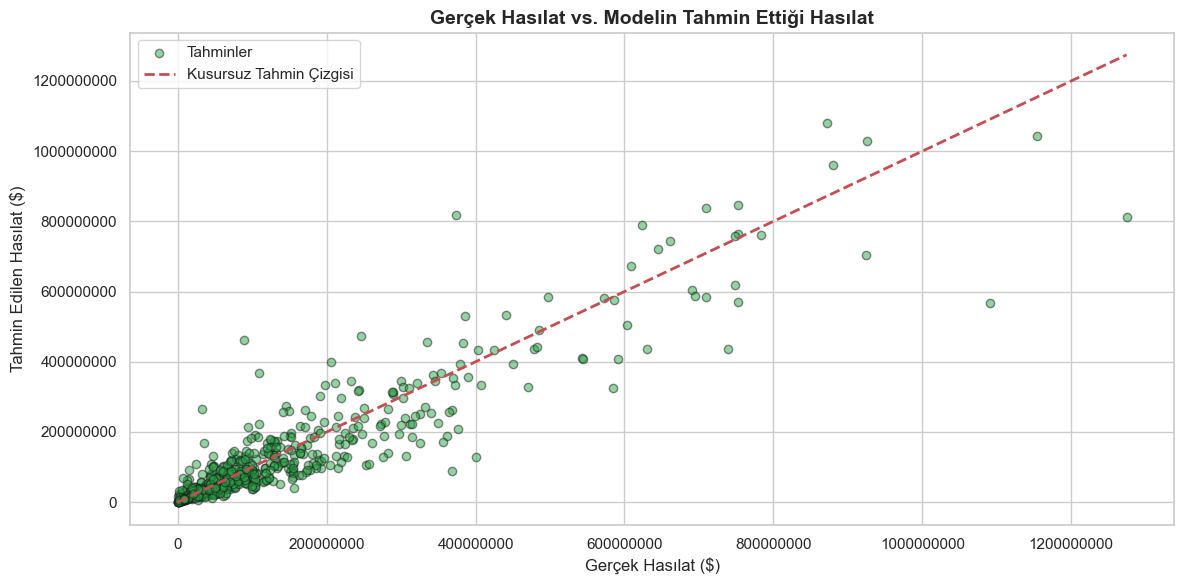

<Figure size 1200x800 with 0 Axes>

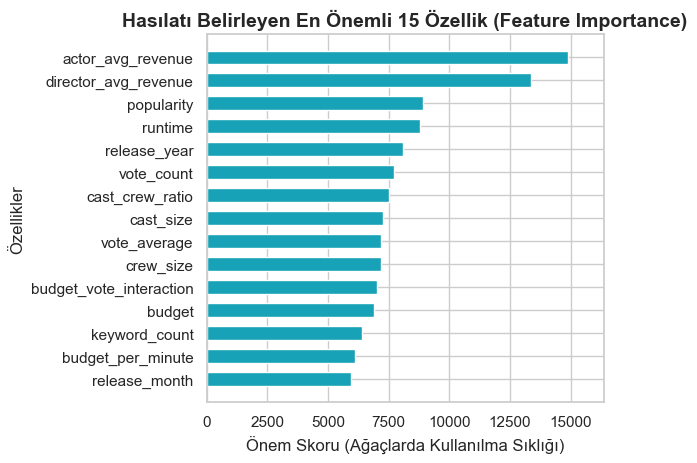

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import xgboost as xgb

# (Eğer modeli yeni bir oturumda açıyorsan aşağıdaki iki satırın başındaki '#' işaretini kaldırıp modeli yükleyebilirsin)
best_model = xgb.XGBRegressor()
best_model.load_model("tmdb_xgboost_best_model.json")

print("Değerlendirme metrikleri ve grafikler hazırlanıyor...")

# 1. Test seti üzerinde tahmin yapma ve logaritmadan (expm1 ile) gerçek dolar değerine dönme
y_pred_log = best_model.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

# 2. METRİKLERİN HESAPLANMASI
r2 = r2_score(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
mape = mean_absolute_percentage_error(y_test_real, y_pred_real) * 100  # Yüzdelik Hata Oranı

print("="*55)
print("📊 MODEL DEĞERLENDİRME RAPORU")
print("="*55)
print(f"🎯 R2 Skoru (Açıklanabilirlik) : {r2:.4f} (Model verinin %{r2*100:.1f}'ini açıklıyor)")
print(f"📉 RMSE (Ort. Karekök Hata)    : ${rmse:,.2f} (Büyük hataları cezalandırır)")
print(f"📉 MAE (Ort. Mutlak Hata)      : ${mae:,.2f} (Ortalama sapma miktarı)")
print(f"📉 MAPE (Ort. Yüzde Hata)      : %{mape:.2f} (Tahminler ortalama %{mape:.2f} sapıyor)")
print("="*55)
# Analiz sonuçlarını bir metin dosyasına yazdırma
analiz_dosyasi = "model_analiz_raporu.txt"

with open(analiz_dosyasi, "w", encoding="utf-8") as f:
    f.write("="*55 + "\n")
    f.write("📊 TMDB HASILAT TAHMİN MODELİ ANALİZ RAPORU\n")
    f.write("="*55 + "\n")
    f.write(f"🎯 R2 Skoru (Açıklanabilirlik) : {r2:.4f}\n")
    f.write(f"📉 RMSE (Ort. Karekök Hata)    : ${rmse:,.2f}\n")
    f.write(f"📉 MAE (Ort. Mutlak Hata)      : ${mae:,.2f}\n")
    f.write(f"📉 MAPE (Ort. Yüzde Hata)      : %{mape:.2f}\n")
    f.write("-" * 55 + "\n")
    f.write(f"📅 Rapor Tarihi: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"💻 Donanım: NVIDIA GeForce RTX 4050 GPU Kullanıldı\n")
    f.write("="*55 + "\n")

print(f"✅ Analiz raporu '{analiz_dosyasi}' dosyasına başarıyla kaydedildi.")

# Grafiklerin daha şık görünmesi için Seaborn stili
sns.set_theme(style="whitegrid")

# 3. GÖRSELLEŞTİRME: Gerçek Hasılat vs Tahmin Edilen Hasılat
plt.figure(figsize=(12, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='#28a745', label='Tahminler', edgecolor='k')

# Kusursuz tahmin çizgisi (Kırmızı kesik çizgi)
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Kusursuz Tahmin Çizgisi')

plt.xlabel('Gerçek Hasılat ($)', fontsize=12)
plt.ylabel('Tahmin Edilen Hasılat ($)', fontsize=12)
plt.title('Gerçek Hasılat vs. Modelin Tahmin Ettiği Hasılat', fontsize=14, fontweight='bold')
plt.legend()
plt.ticklabel_format(style='plain', axis='both') # Bilimsel gösterimi (1e8 gibi) kapatır
plt.tight_layout()
plt.savefig('gercek_vs_tahmin.png', dpi=300)  # Grafiği yüksek çözünürlükte kaydet
plt.show()
# 4. GÖRSELLEŞTİRME: Özellik Önemi (Feature Importance)
# Model hasılatı tahmin ederken en çok hangi sütunlara bakmış?
plt.figure(figsize=(12, 8))
# XGBoost'un yerleşik plot_importance fonksiyonunu kullanıyoruz
ax = xgb.plot_importance(best_model, max_num_features=15, height=0.6, 
                         importance_type='weight', show_values=False, color='#17a2b8')
plt.title('Hasılatı Belirleyen En Önemli 15 Özellik (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Önem Skoru (Ağaçlarda Kullanılma Sıklığı)')
plt.ylabel('Özellikler')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)  # Grafiği yüksek çözünürlükte kaydet
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# 1. Hasılat verilerini anlamlı kategorilere bölüyoruz (Örn: Milyon Dolar cinsinden)
def categorize_revenue(val):
    if val <= 50e6: return 'Düşük Bütçeli (0-50M)'
    if val <= 150e6: return 'Orta Ölçekli (50-150M)'
    if val <= 400e6: return 'Yüksek Gişe (150-400M)'
    return 'Blockbuster (400M+)'

# Gerçek ve tahmin edilen değerleri etiketlere dönüştür
y_test_cat = [categorize_revenue(x) for x in y_test_real]
y_pred_cat = [categorize_revenue(x) for x in y_pred_real]

# Etiketlerin sırasını belirle (Grafikte düzgün dizilmesi için)
labels = ['Düşük Bütçeli (0-50M)', 'Orta Ölçekli (50-150M)', 'Yüksek Gişe (150-400M)', 'Blockbuster (400M+)']

# 2. Confusion Matrix Hesapla
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=labels)

# 3. Görselleştirme
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())

plt.title('Hasılat Segmentlerine Göre Karışıklık Matrisi', fontsize=14, fontweight='bold')
plt.xlabel('Modelin Tahmini', fontsize=12)
plt.ylabel('Gerçek Hasılat', fontsize=12)
plt.xticks(rotation=45)
plt.grid(False) # Izgaraları kapat
plt.savefig('confusion_matrix.png', dpi=300)  # Grafiği yüksek çözünürlükte kaydet
plt.show()